## TP6 - Michel Jean Joseph Donnet

In [1]:
## imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from joblib import Parallel, delayed
import pandas as pd
from IPython.display import display

### PART 1 - Monday, November 28, 2022

In [2]:
# function f(x, y)
def f(x,y):
    ## TODO
    '''
    returns result of function f(x, y) which we are trying to minimize

    Parameters:
    -----------
    x : x-coordinate of point (can be an array of x-coordinates)
    y: y-coordinate of point (can be an array of y-coordinates)

    Returns:
    --------
    result f(x, y) (can be an array of function evaluations)
    '''
    return - np.abs(1 / 2 * x * np.sin(np.sqrt(np.abs(x)))) - np.abs(y * np.sin(30 * np.sqrt(np.abs(x / y))))

##### Visualize the function to minimize in a 3D space to get an idea on how difficult is to find its global minimum, and localize its global minimum.

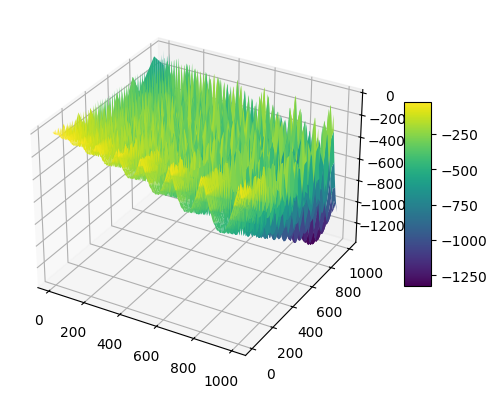

In [3]:
# Plot 3D-plot of f(x, y), with x=[10, 1000] & y=[10, 1000]
x = np.linspace(10, 1000, 1000)
y = np.linspace(10, 1000, 1000)

X, Y = np.meshgrid(x, y)

Z = f(X, Y)

plt.figure()
ax = plt.axes(projection='3d')
colorbar = ax.plot_surface(X, Y, Z, cmap='viridis')
plt.colorbar(colorbar, shrink=0.5, aspect=7)


In [4]:
# Get the optimum point: min of f(x, y) (and save)
opt = np.min(Z)
idx = np.unravel_index(np.argmin(Z), Z.shape)
opt_coord = x[idx[1]], y[idx[0]]
assert opt == f(opt_coord[0], opt_coord[1]), "Coordinates of optimum not found !"
print(f"Optimum value: {opt}")

# save the point 1% away from minimum
opt1 = opt - opt * 0.01

# save the point 2.5% away from the minimum
opt2p5 = opt - opt * 0.025

Optimum value: -1356.4977065634891


In [5]:
# map function from binary to [10, 1000]
def map_xy(xy, l, a, b):
    ## TODO
    '''
    maps binary string to natural number in range of natural numbers [a, b]

    Parameters:
    -----------
    xy : binary string, x or y coordinate to be mapped to a natural number in range [a, b]
    l : length of string 
    a : lower range limit
    b : upper range limit

    Returns:
    --------
    integer value in the range [a, b]
    '''
    return int(xy, 2) / 2**l * (b - a) + a

In [6]:
def generate_gen(N, k):
    ## TODO
    '''
    generates N populations of k-bits each 
    (first k/2 bits are x binary coordinates, and second k/2 bits are y-binary coordinates)

    Parameters:
    -----------
    N : population size
    k: binary x-y coordinate size

    Returns:
    --------
    gen: generation of N individuals of k-bits each
    '''
    return np.random.randint(0, 2, size=(N, k))

def calculate_fitness(gen):
    ## TODO
    '''
    calculates the fitness of generation

    Parameters:
    -----------
    gen : generation of N individuals of k-bits each
    k: binary x-y coordinate size

    Returns:
    --------
    g_fitness : fitness of generation (fitness for each individual in the N population)
    '''
    array2string = lambda x: "".join(map(str, x))
    ## map coordinates
    l = gen.shape[1] // 2
    assert l == gen.shape[1] / 2, "Length of string must be divisible by 2"
    x = np.array([map_xy(array2string(individu), l, 10, 1000) for individu in gen[:, :l]])
    y = np.array([map_xy(array2string(individu), l, 10, 1000) for individu in gen[:, l:]])

    ## get fitness
    return f(x, y)

In [7]:
def select(gen, N):
    ## TODO
    '''
    performs 5-Tournament Selection on generation
    (choose 5 random individuals, return the best one in terms of fitness, repeat process N times)

    Parameters:
    -----------
    gen : generation of N individuals of k-bits each
    N: population size

    Returns:
    --------
    gen: generation gen after selection process

    NOTE: remember to repeat selection process N times to keep a constant population size
    '''
    selection = np.zeros_like(gen)
    for i in range(N):
        choice = gen[np.random.choice(N, size=5)]
        fitness = calculate_fitness(choice)
        selection[i] = choice[np.argmin(fitness)].copy()
    return selection
    

def crossover(gen, k, p_c):
    ## TODO
    '''
    performs One-Point Mid-Break Crossover 
    (choose one point, in the middle of the bit string, to perform Crossover, repeat N/2 times)

    Parameters:
    -----------
    gen : generation of N individuals of k-bits each
    k : size of individual (length of bit string)
    p_c : probability of crossover

    Returns:
    --------
    gen: generation gen after crossover process

    NOTE: remember to repeat selection process N/2 times to keep a constant population size
    '''
    ## pair individuals, decide to perform crossover or not depending on probability c_p
    for i in range(0, gen.shape[0] - 1, 2):
        if np.random.rand() <= p_c:
            assert k % 2 == 0, "k is not divisible by 2 !"
            threshold1 = (k // 2) // 2
            threshold2 = k // 2 + (k // 2) // 2
            gen[i, :threshold1], gen[i + 1, :threshold1] = gen[i + 1, :threshold1], gen[i, :threshold1]
            gen[i, threshold2:], gen[i + 1, threshold2:] = gen[i + 1, threshold2:], gen[i, threshold2:]
    return gen


def mutation(gen, m_p):
    ## TODO
    '''
    performs mutation to each individual in generation gen
    (with a probability m_p for every individual, decide to swap every element of an individual 0->1 or 1->0)

    Parameters:
    -----------
    gen : generation of N individuals of k-bits each
    p_m : probability of mutation

    Returns:
    --------
    gen: generation gen after mutation process
    '''
    prob = np.random.rand(gen.shape[0]) <= m_p
    # Each time we perform a mutation, we generate some random mask that follows uniform distribution.
    # So it means that approximatively the half of the bits will have a mutation for the selected individual.
    mask = np.random.randint(0, 2, size=(np.sum(prob), gen.shape[1])).astype(int)
    gen = gen.astype(int)
    gen[prob] ^= mask
    return gen



In [8]:
## Test selection, crossover, & mutation functions with small N=5 & k=10
N = 5
k = 10
gen = generate_gen(N, k)
print("Generation generated")
print(gen)
print("Fitness of generated generation")
print(calculate_fitness(gen))
selection = select(gen, N)
print("Selected generation")
print(selection)
cross = crossover(selection, k, 0.5)
print("Crossover")
print(cross)
print("Mutation")
print(mutation(cross, 0.5))

Generation generated
[[0 1 0 1 0 0 1 1 1 1]
 [1 1 1 0 0 1 0 1 0 1]
 [1 0 0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 0 1 1 0]
 [0 0 1 0 0 1 0 0 0 1]]
Fitness of generated generation
[-363.50121576 -436.92763238 -128.37330345 -149.9088958  -410.14899539]
Selected generation
[[0 0 1 0 0 1 0 0 0 1]
 [1 1 1 0 0 1 0 1 0 1]
 [1 1 1 0 0 1 0 1 0 1]
 [0 0 1 0 0 1 0 0 0 1]
 [0 1 0 1 0 0 1 1 1 1]]
Crossover
[[0 0 1 0 0 1 0 0 0 1]
 [1 1 1 0 0 1 0 1 0 1]
 [0 0 1 0 0 1 0 0 0 1]
 [0 0 1 0 0 1 0 0 0 1]
 [0 1 0 1 0 0 1 1 1 1]]
Mutation
[[0 0 1 0 0 1 0 0 0 1]
 [1 0 1 0 0 1 1 1 1 1]
 [0 0 1 0 0 1 0 0 0 1]
 [0 0 1 0 1 1 0 1 1 0]
 [1 0 1 0 0 0 1 0 0 1]]


### PART 2 - Monday, December 5, 2022

In [9]:
def GA(N, k, p_c, p_m, evals, crossOver=True, track_best=True):
    ## TODO
    '''
    performs Genetic Algorithm 
    (choose number of iterations depending on number of evaluations needed where: 
    num_evaluations = population_size * num_iterations)

    Parameters:
    -----------
    N : population size
    k : size of individual (length of bit string)
    p_c : probability of crossover
    p_m : probability of mutation
    evals : number of evaluations
    crossOver : =True to perform crossover, & False otherwise
    track_best: =True to keep track of best seen so far for each individual, & False otherwise

    Returns:
    --------
    gen: generation gen after number of evaluations
    g_fitness : generations fitness (N fitnesses)
    fit_best : best so far for each individual (list of zeros in case track_best=False)
    probs : list of empirical probabilities (relative frequencies), of individuals reaching optimum, at each iteration
    probs1 : list of empirical probabilities (relative frequencies), of individuals at most 1% away from optimum, at each iteration
    probs2p5 : list of empirical probabilities (relative frequencies), of individuals at most 2.5% away from optimum, at each iteration
    '''
    # generate a population of N individuals, of k-bit strings each
    gen = generate_gen(N, k)

    ## fit_best : to update in case of track_best=True
    fit_best = np.zeros(N)
    # list of empirical probabilities (relative frequencies), 
    # of individuals reaching optimum, at each iteration
    probs = []
    # list of empirical probabilities (relative frequencies), 
    # of individuals reaching at most 1% away from optimum, at each iteration
    probs1 = []
    # list of empirical probabilities (relative frequencies), 
    # of individuals reaching at most 2.5% away from optimum, at each iteration
    probs2p5 = []
    
    ## number of iterations can be calculated from: num_evaluations = population_size * num_iterations
    # TODO
    iterations  = evals // N
    for _ in range(iterations):
        ## selection 
        gen = select(gen, N)
        ## crossover (if True)
        if crossOver:
            crossover(gen, k, p_c)
        ## mutation
        mutation(gen, p_m)
        ## get fitness
        g_fitness = calculate_fitness(gen)
        ## append empirical probabilities depending on keeping track of best or not
        probs.append(np.sum(g_fitness == opt) / N)
        probs1.append(np.sum(g_fitness <= opt1) / N)
        probs2p5.append(np.sum(g_fitness <= opt2p5) / N)
        if track_best:
            fit_best[fit_best > g_fitness] = g_fitness[fit_best > g_fitness]

    return gen, g_fitness, fit_best, probs, probs1, probs2p5

Experiment GA algorithm for all combinations of the following cases:

1. p_m = 0.01 or p_m = 0.1
2. no crossover or crossover with p_c = 0.6
(4 cases in total)

For each of the 4 cases, run with/out keeping track of best
-> (8 cases in total)

In all cases: N=100, k=20

In [10]:
# population size
N = 100
# individual bit string
k = 20
### Run GA for all above cases 10 times
def utilities(evals: int = 1e3, p_m: float = 0.1, p_c: float = 0.6, track: bool = True, crossOver: bool = True, N: int = 100, k: int = 20, idx: int = 1) -> np.array:
    result = Parallel(n_jobs=-1)(
        delayed(GA)(N, k, p_c, p_m, evals=int(evals), crossOver=crossOver, track_best=track) for _ in range(10)
    )
    return result

def get_elem(result, idx: int = 1):
    return np.array([elem[idx] for elem in result])

Statistics: 
Get best, mean, standard deviation for each of the following 4 cases (no track of best) at 10^3, 10^4, & 10^5 fitness evaluations:
1. p_m = 0.01 & no crossover
2. p_m = 0.01 & p_c = 0.6
3. p_m = 0.1 & no crossover
4. p_m = 0.1 & p_c = 0.6

Print the statistics nicely (you can use pandas dataframe for eg.)
Results are 4 tables of 9 values each

In [11]:
## Statistics
stat = []
for eval in [1e3, 1e4, 1e5]:
    tmp = get_elem(utilities(evals=int(eval), p_m = 0.01, crossOver=False))
    stat.append(np.min(tmp))
    stat.append(np.mean(tmp))
    stat.append(np.std(tmp))
stat = np.array(stat).reshape(3, 3)
print(f"p_m = 0.01 & no crossover")
display(pd.DataFrame(stat, columns=["Best fitness", "Mean", "Standard deviation"], index=["10³", "10⁴", "10⁵"]))

stat = []
for eval in [1e3, 1e4, 1e5]:
    tmp = get_elem(utilities(evals=int(eval), p_m = 0.01, p_c = 0.6))
    stat.append(np.min(tmp))
    stat.append(np.mean(tmp))
    stat.append(np.std(tmp))
stat = np.array(stat).reshape(3, 3)
print(f"p_m = 0.01 & p_c = 0.6")
display(pd.DataFrame(stat, columns=["Best fitness", "Mean", "Standard deviation"], index=["10³", "10⁴", "10⁵"]))

stat = []
for eval in [1e3, 1e4, 1e5]:
    tmp = get_elem(utilities(evals=int(eval), p_m = 0.1, crossOver=False))
    stat.append(np.min(tmp))
    stat.append(np.mean(tmp))
    stat.append(np.std(tmp))
stat = np.array(stat).reshape(3, 3)
print(f"p_m = 0.1 & no crossover")
display(pd.DataFrame(stat, columns=["Best fitness", "Mean", "Standard deviation"], index=["10³", "10⁴", "10⁵"]))

stat = []
for eval in [1e3, 1e4, 1e5]:
    tmp = get_elem(utilities(evals=int(eval), p_m = 0.1, p_c = 0.6))
    stat.append(np.min(tmp))
    stat.append(np.mean(tmp))
    stat.append(np.std(tmp))
stat = np.array(stat).reshape(3, 3)
print(f"p_m = 0.1 & p_c = 0.6")
display(pd.DataFrame(stat, columns=["Best fitness", "Mean", "Standard deviation"], index=["10³", "10⁴", "10⁵"]))

p_m = 0.01 & no crossover


,Best fitness,Mean,Standard deviation
10³,-1347.120956,-1230.653565,86.362569
10⁴,-1348.862433,-1215.785230,97.540488
10⁵,-1342.120814,-1238.946337,81.911704


p_m = 0.01 & p_c = 0.6


,Best fitness,Mean,Standard deviation
10³,-1351.816557,-1272.392341,42.332101
10⁴,-1341.535961,-1297.229734,40.056473
10⁵,-1354.787155,-1325.404506,24.956133


p_m = 0.1 & no crossover


,Best fitness,Mean,Standard deviation
10³,-1350.834243,-1190.921309,73.314188
10⁴,-1331.202133,-1205.414960,90.037933
10⁵,-1345.446242,-1197.534668,97.525855


p_m = 0.1 & p_c = 0.6


,Best fitness,Mean,Standard deviation
10³,-1354.677009,-1322.577027,33.785339
10⁴,-1352.256242,-1296.792749,43.941342
10⁵,-1353.926597,-1323.314160,39.894723


### Comment on your results (effect of mutation/crossover)

If we look at the results we can see that each time the code is runned without crossover, the standard deviation is bigger than when the code is runned with crossover.

So it means that the crossover allows, by mixing up individus, a better convergence to the optimum.
On top of that, we are more close to the optimum when we use crossover: for a population of size $10^5$ with `p_m`$=0.01$, the best fitness obtained without crossover is $-1342$ whereas with crossover, it is of $-1354$, which is closer to optimum of the function ($1356$).

So this means that the crossover allows better convergence and results of the method.

If we take a look at the comparison between `p_m`=0.1 and 0.01, we can see that with probability of mutations of 0.1 the results are a little better than with 0.01, especialy for tests made with crossover.
This means that maintaining some diversity between individu help to reach better values than without diversity.

So mutation, by introducing diversity, allows a better result of the method.

Plot the cumulative empirical probabilities (probabilities vs. fitness evaluations) for all 4 cases for:
1. optimum
2. 1% away from optimum
3. 2.5% away from optimum
All 3 cases are plotted with/out keeping track of best

We expect 6 figures at the end, with each figure having all 4 combinations of crossover & mutation on the same plot

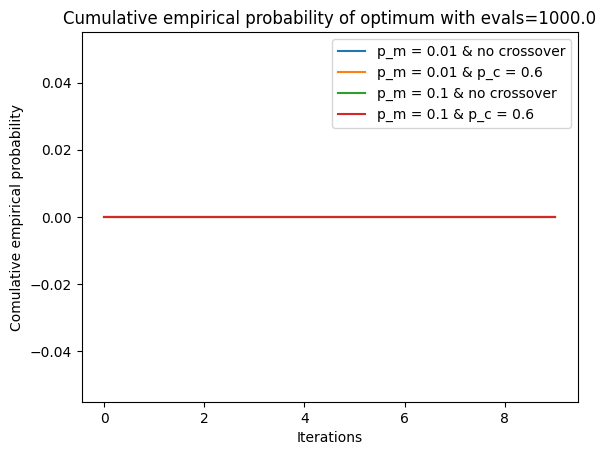

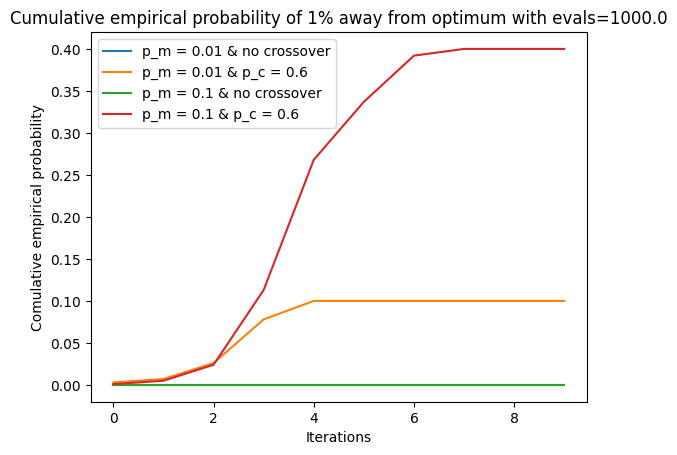

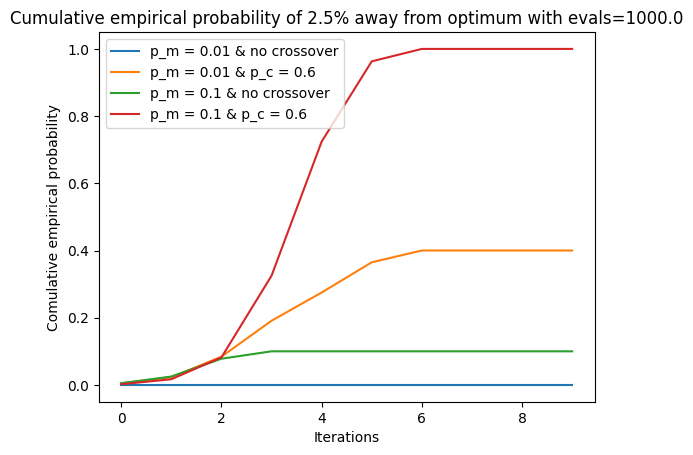

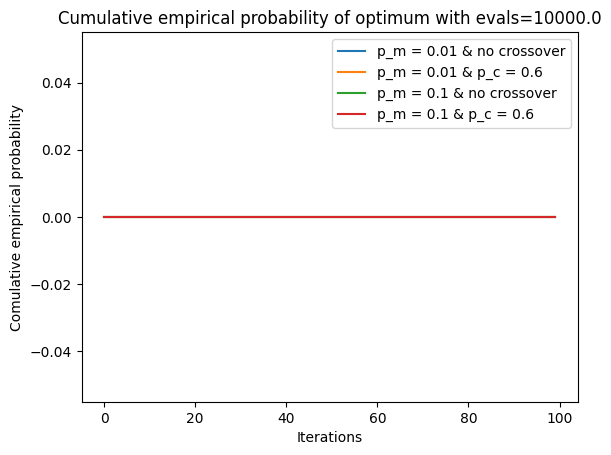

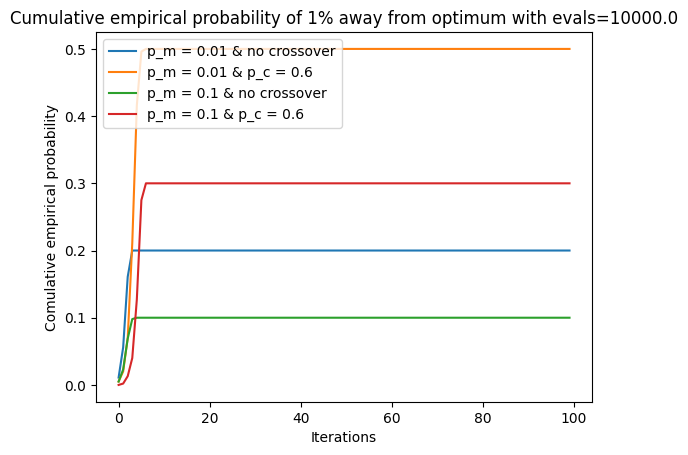

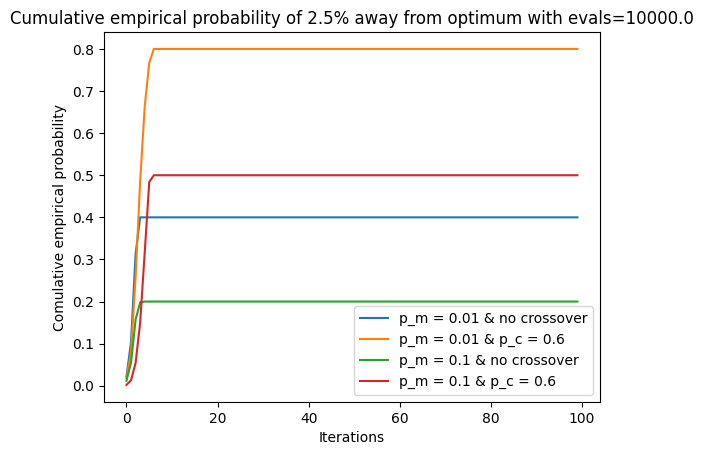

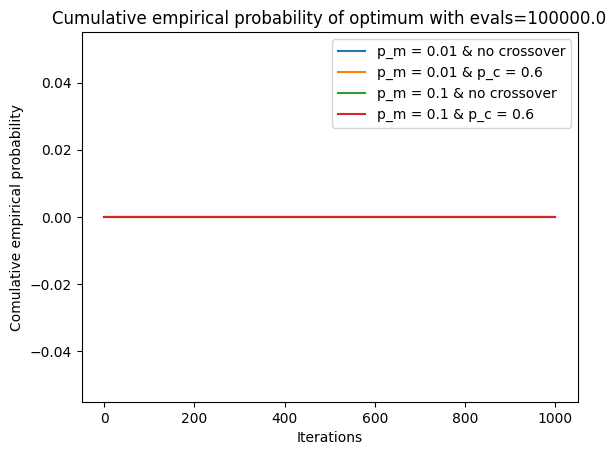

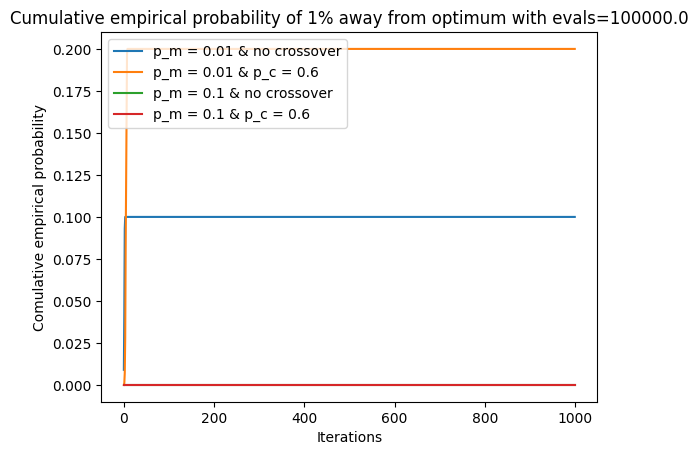

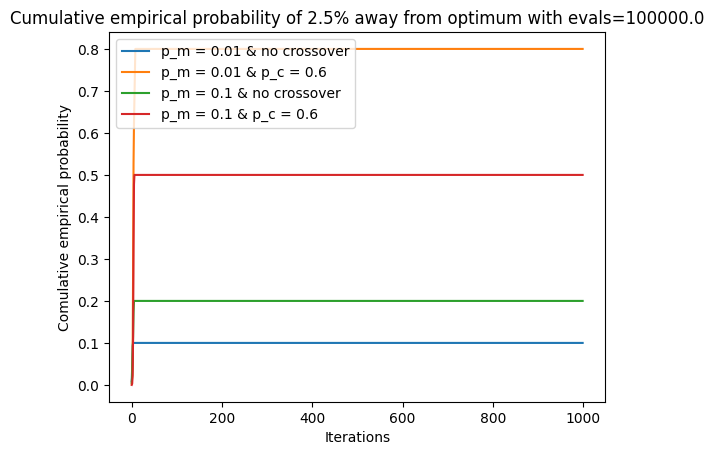

In [15]:
## Cumulative empirical probabilities
for eval in [1e3, 1e4, 1e5]:
    proba = []
    proba1 = []
    proba2p5 = []
    for p_m in [0.01, 0.1]:
        for p_c in [0, 0.6]:
            if p_c == 0:
                tmp = utilities(evals=int(eval), p_m = p_m, crossOver=False)
            else:
                tmp = utilities(evals=int(eval), p_m=p_m, p_c=p_c)
            proba.append((p_m, p_c, get_elem(tmp, idx=3)))
            proba1.append((p_m, p_c, get_elem(tmp, idx=4)))
            proba2p5.append((p_m, p_c, get_elem(tmp, idx=5)))
    plt.figure()
    plt.title(f"Cumulative empirical probability of optimum with evals={eval}")
    for case in proba:
        tmp = np.mean(case[2], axis=0)
        plt.plot(np.arange(tmp.shape[0]), tmp, label=f"p_m = {case[0]} & {"no crossover" if case[1] == 0 else f"p_c = {case[1]}"}")
    plt.xlabel("Iterations")
    plt.ylabel("Comulative empirical probability")
    plt.legend()
    plt.show()

    plt.figure()
    plt.title(f"Cumulative empirical probability of 1% away from optimum with evals={eval}")
    for case in proba1:
        tmp = np.mean(case[2], axis=0)
        plt.plot(np.arange(tmp.shape[0]), tmp, label=f"p_m = {case[0]} & {"no crossover" if case[1] == 0 else f"p_c = {case[1]}"}")
    plt.xlabel("Iterations")
    plt.ylabel("Comulative empirical probability")
    plt.legend()
    plt.show()

    plt.figure()
    plt.title(f"Cumulative empirical probability of 2.5% away from optimum with evals={eval}")
    for case in proba2p5:
        tmp = np.mean(case[2], axis=0)
        plt.plot(np.arange(tmp.shape[0]), tmp, label=f"p_m = {case[0]} & {"no crossover" if case[1] == 0 else f"p_c = {case[1]}"}")
    plt.xlabel("Iterations")
    plt.ylabel("Comulative empirical probability")
    plt.legend()
    plt.show()
            

### Comment on your results (observation, difference between keeping track or not...)

If we take a look on the results, we can easily see that the optimum is never reached.

However, in most of cases, the majority of the populations comes 2.5% near the optimum solution, which is very good.

After executing several times the code, there is a lot of variance in all solutions.
So taking more than $10$ sample of the method could be better to obtain more accurate results.

If we look at the impact of the crossover on the Genetic Algorithm, we can see that in most cases, when there is no crossover, a smaller part of the generation reach a good solution.
For instance, only 10% and 20% of the population get a fitness 2.5% away from the optimum for $10^5$ evaluations whereas 50% and 80% of the generation get a fitness at least at 2.5% away from the optimum.

We can also constate that with a small number of evaluations, results with crossover are better for mutation probability of 0.1 whereas when the number of evaluations increase, the results with mutation probability of 0.01 becomes better.
This means that the mutation probability has a big impact on the method and must be properly set to have good results.
I think that these results are obtained because the mutation bring some diversification in the generation.
However, if we take a huge number of generations, if the mutation is too big, the method will oscillate aroud the best values without reaching it because of too much diversification.

Finally, we can easily constate that the method converge very fastly.
Indeed, only 10 iterations are usefull to have a method that reach its best cumulative empirical probability.
And with a too big number of evaluations, there is less individu that comes near the optimum because there is a maximum of 20% of the population that reach a value 1% away from the optimum for $10^5$ evaluations against 40% for $10^3$ evaluations.

So in genetic algorithms, like in all metaheuristic algorithms, guided parameters must be properly set to have a nice convergence of the method.
And results have shown that for this problem given, a too big number of evaluations is not usefull to get a very good solution.

Answer the following Questions: 

1.  Q: What is the Search Space of our problem?

    A: The search space of the problem can be defined as all combinations of $x$ and $y$ values according to precision of the discretization of the problem. So in our case, according to the precision of the discretisation, the search space can be considered as combinations of $x \in [10, 1000]$ and $y \in [10, 1000]$, making a search space of size $10^4$.


2.  Q: What are the roles of Selection, Crossover, & Mutation processes?

    A: Selection allows to choose best individus in a generation. However, the selection process introduce some stochastisity by for instance choosing each time best individu for a set of 5 individu chosen randomly.
    Crossover allows to mix-up the genes from the two parents to give two children different from parents, but with the genetic material of the parents.
    Mutation process introduces some diversity into the individu.
    In this way, all individus are subject to change a little their genetic material, allowing in this way to have worse individu, but also better individus.
    

3.  Q: What does each of the 3 processes Selection, Crossover & Mutation favor : exploration/diversification or exploitation/intensification?

    A: Selection exploit the current generation by selecting the best individus. Mutation introduces some diversity into the new individu created, allowing more exploration. Finally, crossover promote both exploration and exploitation.
    Indeed, in some case, crossover will only create new individu that are similar to their parents, promoting exploitation, and sometimes, new individus can be much better than their parents, promoting a good exploration.
    So crossover favor both exploration and exploitation.